In [35]:
import pyreadstat
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as cx
import folium
from folium.plugins import HeatMap
import branca.colormap as cm

In [56]:
# Load Houston place boundaries
# Load Houston place boundary
us_places_gdf = gpd.read_file("/home/eprashar_solutions_corelogic_com/crime-idx-2026/data/boundaries/cb_2024_us_place_500k")
houston_city_gdf = us_places_gdf[(us_places_gdf['STATEFP'] == '48') & (us_places_gdf['PLACEFP'] == '35000')].copy()
houston_city_gdf = houston_city_gdf.to_crs("EPSG:4326")
print(f"Houston city boundary loaded: {len(houston_city_gdf)} row(s)")
print(houston_city_gdf[['NAME', 'STATEFP', 'PLACEFP']].values)

Houston city boundary loaded: 1 row(s)
[['Houston' '48' '35000']]


In [21]:
# Load Houston crime data from Police Department
houston_crime_county_csv = f"/home/eprashar_solutions_corelogic_com/crime-idx-2026/data/public/houston/NIBRSPublicView2025.csv"
houston_crime_df = pd.read_csv(houston_crime_county_csv)
print("Houston data loaded!")

Houston data loaded!


/tmp/ipykernel_3679190/3523838074.py:3: DtypeWarning: Columns (0: ZIP Code) have mixed types. Specify dtype option on import or set low_memory=False.
  houston_crime_df = pd.read_csv(houston_crime_county_csv)


In [22]:
# Examine columns and a few rows
print(f"Columns are {houston_crime_df.columns.to_list()}")
print("="*80)
print(houston_crime_df.info())

Columns are ['Incident', 'Occurrence Date', 'Occurrence Hour', 'NIBRS Class', 'NIBRS Description', 'Offense Count', 'Beat', 'Premise', 'Street Number', 'Street Name', 'Street Type', 'Street Suffix', 'City', 'ZIP Code', 'Map Longitude', 'Map Latitude']
<class 'pandas.DataFrame'>
RangeIndex: 240696 entries, 0 to 240695
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Incident           240696 non-null  int64  
 1   Occurrence Date    240696 non-null  str    
 2   Occurrence Hour    240696 non-null  int64  
 3   NIBRS Class        240696 non-null  str    
 4   NIBRS Description  240696 non-null  str    
 5   Offense Count      240696 non-null  int64  
 6   Beat               240520 non-null  str    
 7   Premise            240696 non-null  str    
 8   Street Number      239754 non-null  str    
 9   Street Name        240696 non-null  str    
 10  Street Type        222742 non-null  str    
 11  Street

In [23]:
# Standardize column names to lowercase and add underscores
houston_crime_df.columns = houston_crime_df.columns.str.lower().str.replace(' ', '_')
print(f"Standardized columns: {houston_crime_df.columns.to_list()}")

Standardized columns: ['incident', 'occurrence_date', 'occurrence_hour', 'nibrs_class', 'nibrs_description', 'offense_count', 'beat', 'premise', 'street_number', 'street_name', 'street_type', 'street_suffix', 'city', 'zip_code', 'map_longitude', 'map_latitude']


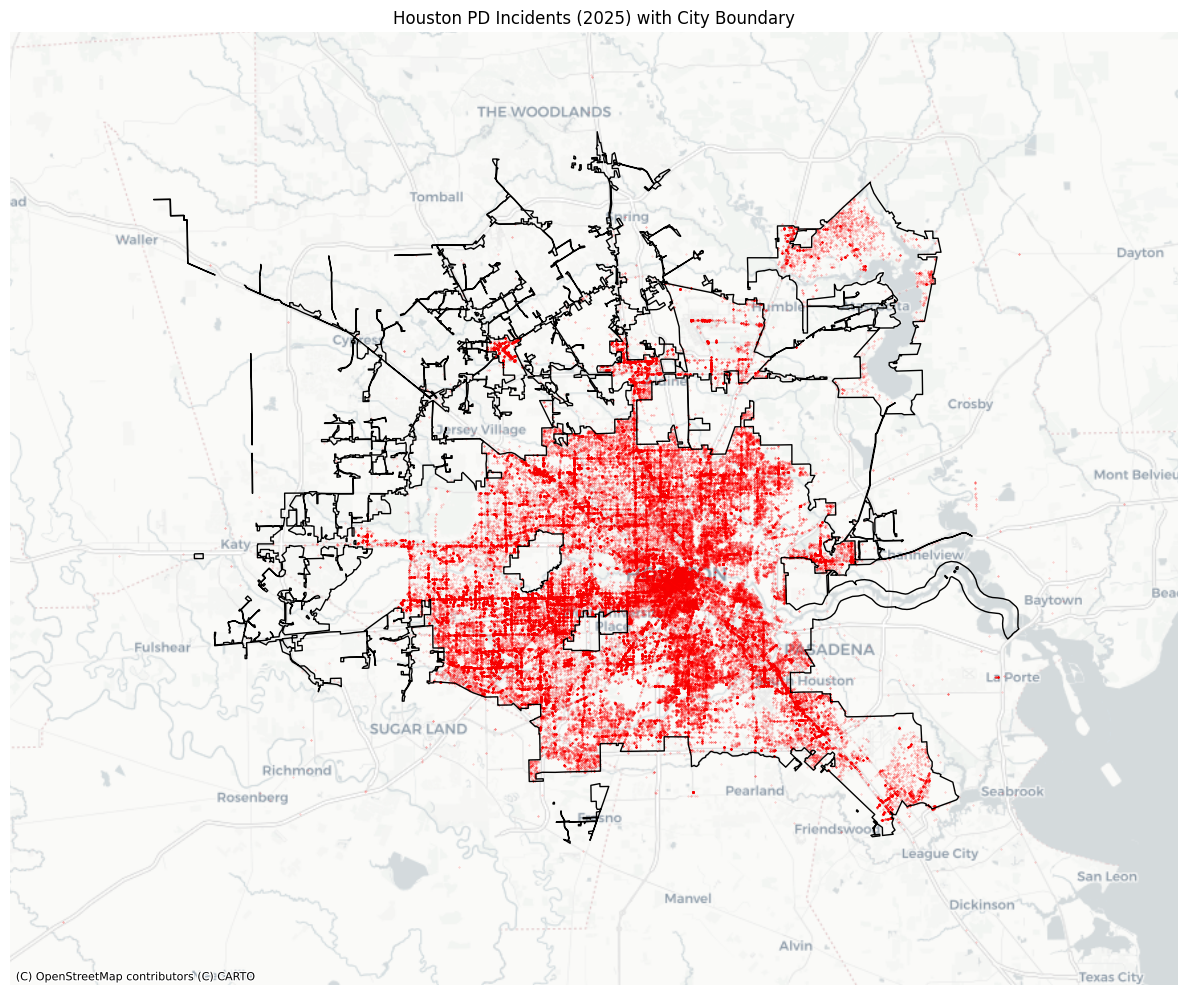

In [59]:
# Quick scatter of all Houston incidents with city boundary
fig, ax = plt.subplots(figsize=(12, 10))
houston_crime_valid = houston_crime_df.dropna(subset=['map_latitude', 'map_longitude'])
gdf = gpd.GeoDataFrame(houston_crime_valid, 
                        geometry=gpd.points_from_xy(houston_crime_valid['map_longitude'], houston_crime_valid['map_latitude']),
                        crs="EPSG:4326")
gdf = gdf.to_crs(epsg=3857)
gdf.plot(ax=ax, markersize=0.1, alpha=0.3, color='red')
houston_city_gdf.to_crs(epsg=3857).boundary.plot(ax=ax, color='black', linewidth=1, label='Houston City Boundary')
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_title("Houston PD Incidents (2025) with City Boundary")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [28]:
# Load TX block group boundaries
tx_bg_gdf = gpd.read_file("/home/eprashar_solutions_corelogic_com/crime-idx-2026/data/boundaries/cb_2025_48_bg_500k.zip")
print(f"TX block groups loaded: {len(tx_bg_gdf):,}")
print(f"Columns: {tx_bg_gdf.columns.tolist()}")
print(f"CRS: {tx_bg_gdf.crs}")
print(tx_bg_gdf.head())

TX block groups loaded: 18,626
Columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'BLKGRPCE', 'GEOIDFQ', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD', 'ALAND', 'AWATER', 'geometry']
CRS: EPSG:4269
  STATEFP COUNTYFP TRACTCE BLKGRPCE                GEOIDFQ         GEOID NAME  \
0      48      315  950100        2  1500000US483159501002  483159501002    2   
1      48      113  007604        1  1500000US481130076041  481130076041    1   
2      48      113  016530        1  1500000US481130165301  481130165301    1   
3      48      167  721211        3  1500000US481677212113  481677212113    3   
4      48      157  672003        1  1500000US481576720031  481576720031    1   

        NAMELSAD LSAD      ALAND    AWATER  \
0  Block Group 2   BG  179314815  30997329   
1  Block Group 1   BG    1504070         0   
2  Block Group 1   BG    2616000      3623   
3  Block Group 3   BG    4148433       413   
4  Block Group 1   BG    6614180     17905   

                                            geometry  


In [29]:
# Standardize column names to lowercase and add underscores
tx_bg_gdf['county_fips'] = tx_bg_gdf['STATEFP'] + tx_bg_gdf['COUNTYFP']
tx_bg_gdf.columns = tx_bg_gdf.columns.str.lower().str.replace(' ', '_')
tx_bg_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 18626 entries, 0 to 18625
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   statefp      18626 non-null  str     
 1   countyfp     18626 non-null  str     
 2   tractce      18626 non-null  str     
 3   blkgrpce     18626 non-null  str     
 4   geoidfq      18626 non-null  str     
 5   geoid        18626 non-null  str     
 6   name         18626 non-null  str     
 7   namelsad     18626 non-null  str     
 8   lsad         18626 non-null  str     
 9   aland        18626 non-null  int64   
 10  awater       18626 non-null  int64   
 11  geometry     18626 non-null  geometry
 12  county_fips  18626 non-null  str     
dtypes: geometry(1), int64(2), str(10)
memory usage: 1.8 MB


In [43]:
# Create point geometries
geometry = [Point(xy) for xy in zip(houston_crime_valid['map_longitude'], houston_crime_valid['map_latitude'])]
houston_gdf = gpd.GeoDataFrame(houston_crime_valid, geometry=geometry, crs="EPSG:4326")

# Ensure same CRS
tx_bg_gdf = tx_bg_gdf.to_crs("EPSG:4326")

# Keep block group geometry as a separate column before join
tx_bg_gdf['bg_geo'] = tx_bg_gdf.geometry

# Spatial join (keeps crime point geometry as the active geometry)
houston_crime_bg = gpd.sjoin(houston_gdf, tx_bg_gdf[['county_fips', 'geoid', 'bg_geo', 'geometry']], how='left', predicate='within')
houston_crime_bg = houston_crime_bg.rename(columns={'geoid': 'bg_key', 'geometry': 'crime_geo'})

# Drop index_right (from spatial join)
houston_crime_bg = houston_crime_bg.drop(columns=['index_right'])

print(f"Records matched to a block group: {houston_crime_bg['bg_key'].notna().sum():,}")
print(f"Records NOT matched: {houston_crime_bg['bg_key'].isna().sum():,}")

Records matched to a block group: 236,917
Records NOT matched: 94


In [50]:
# Check block group aggregates
houston_crime_bg_agg = houston_crime_bg.groupby(['bg_key','bg_geo']).size().reset_index(name='crime_count')
houston_crime_bg_agg['county_fips'] = houston_crime_bg_agg['bg_key'].str[:5]
houston_crime_bg_agg.info()
print("="*80)
print(f"Unique counties in agg: {houston_crime_bg_agg['county_fips'].nunique()}")
print(houston_crime_bg_agg['county_fips'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 2079 entries, 0 to 2078
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   bg_key       2079 non-null   str     
 1   bg_geo       2079 non-null   geometry
 2   crime_count  2079 non-null   int64   
 3   county_fips  2079 non-null   str     
dtypes: geometry(1), int64(1), str(2)
memory usage: 65.1 KB
Unique counties in agg: 8
county_fips
48201    1975
48157      72
48039      10
48339      10
48167       7
48473       3
48071       1
48291       1
Name: count, dtype: int64


count    2079.000000
mean      113.957191
std       147.834063
min         1.000000
25%        19.000000
50%        73.000000
75%       155.500000
max      1834.000000
Name: crime_count, dtype: float64
Block groups with zero crimes: 0 / 2,079 (0.00%)
  P 1:        1   (2,079 block groups >= this value)
  P 5:        1   (2,079 block groups >= this value)
  P10:        2   (1,880 block groups >= this value)
  P25:       19   (1,567 block groups >= this value)
  P50:       73   (1,044 block groups >= this value)
  P75:      156   (520 block groups >= this value)
  P90:      274   (209 block groups >= this value)
  P95:      362   (104 block groups >= this value)
  P99:      648   (21 block groups >= this value)


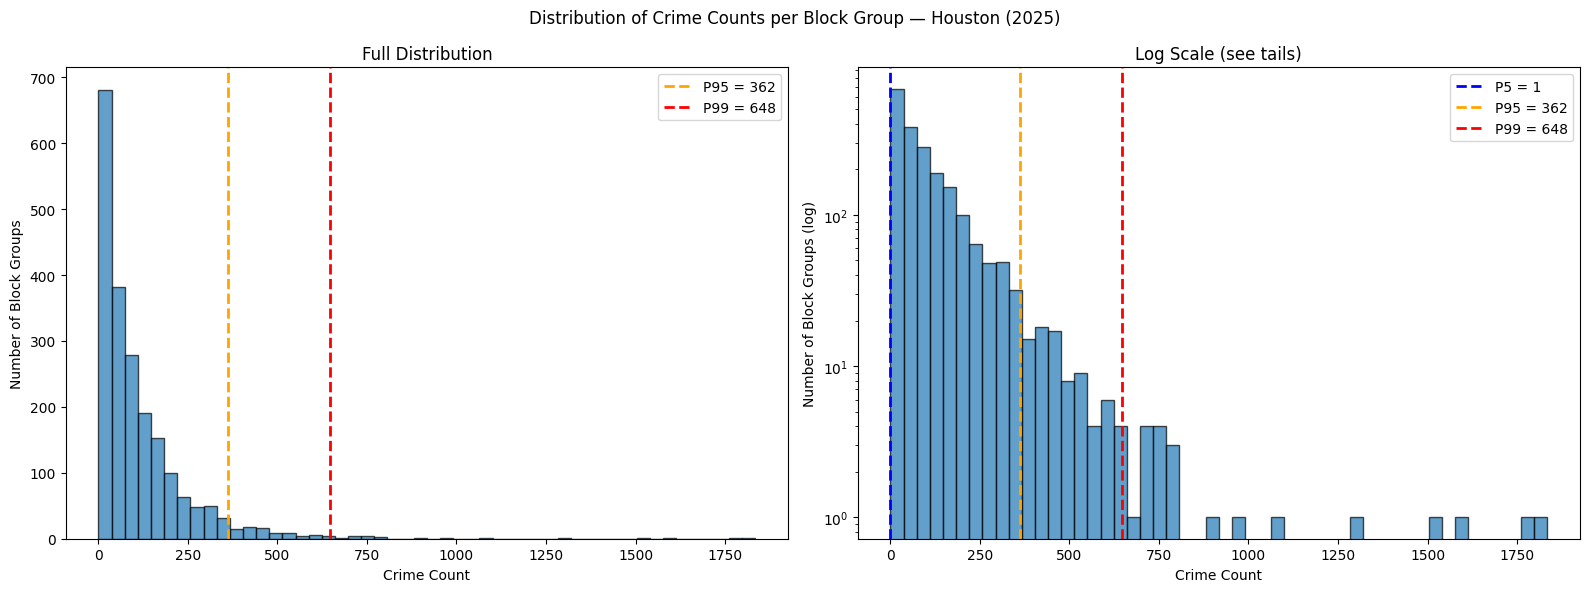

In [63]:
# Check distribution of crime counts across block groups
print(houston_crime_bg_agg['crime_count'].describe())
print("="*80)

# Check block groups with zero crimes
zero_crime_bgs = houston_crime_bg_agg[houston_crime_bg_agg['crime_count'] == 0]
print(f"Block groups with zero crimes: {len(zero_crime_bgs):,} / {len(houston_crime_bg_agg):,} ({len(zero_crime_bgs)/len(houston_crime_bg_agg)*100:.2f}%)")

# Show key percentiles
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    val = houston_crime_bg_agg['crime_count'].quantile(p/100)
    count_at = (houston_crime_bg_agg['crime_count'] >= val).sum()
    print(f"  P{p:>2}: {val:>8.0f}   ({count_at:,} block groups >= this value)")

# Plot histogram with percentile lines
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: full distribution
axes[0].hist(houston_crime_bg_agg['crime_count'], bins=50, edgecolor='black', alpha=0.7)
for p, color in [(95, 'orange'), (99, 'red')]:
    val = houston_crime_bg_agg['crime_count'].quantile(p/100)
    axes[0].axvline(val, color=color, linestyle='--', linewidth=2, label=f'P{p} = {val:.0f}')
axes[0].legend()
axes[0].set_title('Full Distribution')
axes[0].set_xlabel('Crime Count')
axes[0].set_ylabel('Number of Block Groups')

# Right: log scale to see tails better
axes[1].hist(houston_crime_bg_agg['crime_count'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_yscale('log')
for p, color in [(5, 'blue'), (95, 'orange'), (99, 'red')]:
    val = houston_crime_bg_agg['crime_count'].quantile(p/100)
    axes[1].axvline(val, color=color, linestyle='--', linewidth=2, label=f'P{p} = {val:.0f}')
axes[1].legend()
axes[1].set_title('Log Scale (see tails)')
axes[1].set_xlabel('Crime Count')
axes[1].set_ylabel('Number of Block Groups (log)')

plt.suptitle('Distribution of Crime Counts per Block Group — Houston (2025)')
plt.tight_layout()
plt.show()

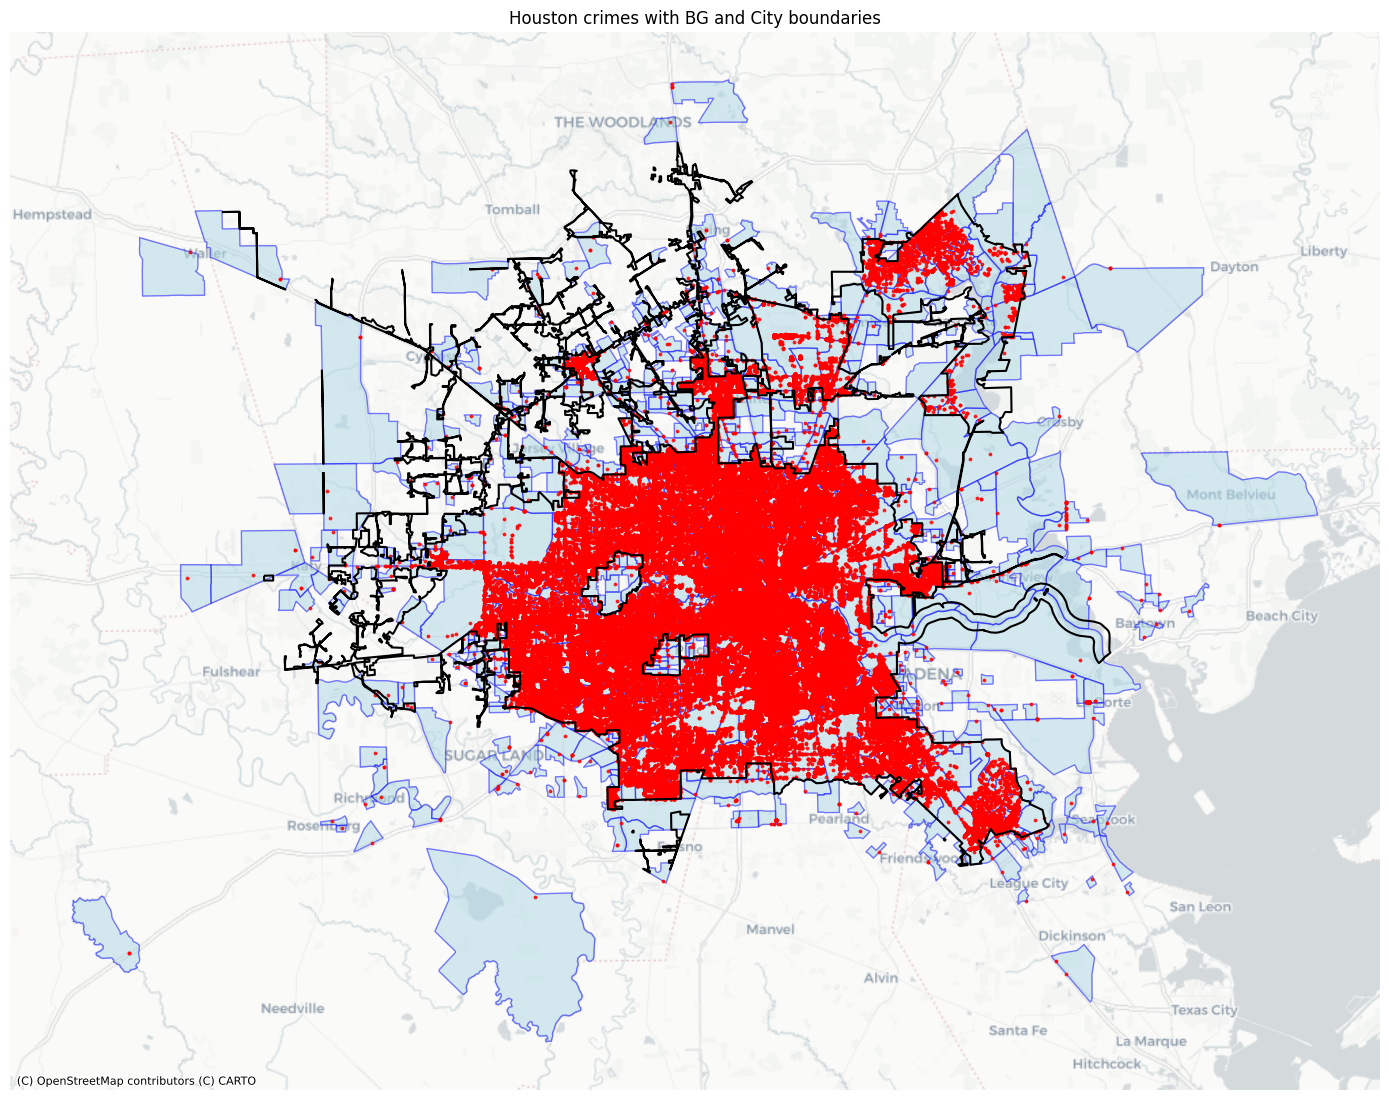

In [61]:
# Convert to GeoDataFrame using bg_geo (polygons) as geometry
houston_crime_bg_agg_gdf = gpd.GeoDataFrame(houston_crime_bg_agg, geometry='bg_geo', crs="EPSG:4326")

# Get crime points inside those block groups
filtered_bg_keys = houston_crime_bg_agg_gdf['bg_key'].unique()
crime_points_in_filtered = houston_crime_bg[houston_crime_bg['bg_key'].isin(filtered_bg_keys)].copy()
crime_points_gdf = gpd.GeoDataFrame(crime_points_in_filtered, geometry='crime_geo', crs="EPSG:4326")

# Static map: polygons + crime points
fig, ax = plt.subplots(figsize=(14, 12))
# Plot block group boundaries in light grey
houston_crime_bg_agg_gdf.to_crs(epsg=3857).plot(ax=ax, color='lightblue', edgecolor='blue', linewidth=1, alpha=0.5)
# Crime points in red
crime_points_gdf.to_crs(epsg=3857).plot(ax=ax, color='red', markersize=3, alpha=0.8)
# City boundary in black
houston_city_gdf.to_crs(epsg=3857).boundary.plot(ax=ax, color='black', linewidth=1.5)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_title(f"Houston crimes with BG and City boundaries")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [62]:
# Folium map
m = folium.Map(location=[29.76, -95.37], zoom_start=10, tiles='CartoDB positron')

# Block group polygons
folium.GeoJson(
    houston_crime_bg_agg_gdf,
    style_function=lambda f: {
        'fillColor': 'lightblue',
        'color': 'blue',
        'weight': 1,
        'fillOpacity': 0.3,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['bg_key', 'crime_count'],
        aliases=['Block Group:', 'Crime Count:'],
        sticky=True
    )
).add_to(m)

# Houston city boundary
folium.GeoJson(
    houston_city_gdf.boundary,
    style_function=lambda f: {
        'color': 'black',
        'weight': 2,
    }
).add_to(m)

# Crime points as a HeatMap (plotting 100k+ individual markers would freeze the browser)
heat_data = crime_points_gdf[['crime_geo']].copy()
heat_data['lat'] = crime_points_gdf.geometry.y
heat_data['lon'] = crime_points_gdf.geometry.x
HeatMap(heat_data[['lat', 'lon']].values.tolist(), radius=6, blur=10, max_zoom=13).add_to(m)

m.save('/home/eprashar_solutions_corelogic_com/crime-idx-2026/notebooks/houston_bg_crimes_all.html')
print(f"Saved houston_bg_crimes_all.html — {len(houston_crime_bg_agg_gdf):,} block groups, {len(crime_points_gdf):,} crime points")

Saved houston_bg_crimes_all.html — 2,079 block groups, 236,917 crime points


In [10]:
# See what offense categories exist in the data
print(f"Unique NIBRS Class values: {houston_joined['NIBRS Class'].nunique()}")
print("="*80)
print(houston_joined[['NIBRS Class','NIBRS Description']].value_counts())

Unique NIBRS Class values: 60
NIBRS Class  NIBRS Description                        
13B          Simple assault                               24248
23F          Theft from motor vehicle                     23861
290          Destruction, damage, vandalism               20426
13C          Intimidation                                 18577
23H          All other larceny                            17451
23C          Shoplifting                                  16949
90Z          All other offenses                           16643
13A          Aggravated Assault                           13041
240          Motor vehicle theft                          12355
220          Burglary, Breaking and Entering              11284
90J          Trespass of real property                    10964
23G          Theft of motor vehicle parts or accessory     8044
35A          Drug, narcotic violations                     7995
120          Robbery                                       4973
90D          Drivin

In [11]:
# Map NIBRS Class codes to our crime risk model categories
nibrs_to_category = {
    # Assault
    '13A': 'assault',
    # NOTE: 13B and 13C are not included in model mapping
    # '13B': 'assault', '13C': 'assault',
    # Burglary
    '220': 'burglary',
    # Larceny (all theft subtypes)
    '23A': 'larceny', '23B': 'larceny', '23C': 'larceny', '23D': 'larceny',
    '23E': 'larceny', '23F': 'larceny', '23G': 'larceny', '23H': 'larceny',
    # Murder
    '09A': 'murder', '09B': 'murder', '09C': 'murder',
    # Motor Vehicle Theft
    '240': 'mvt',
    # Rape / Sexual assault
    '11A': 'rape', '11B': 'rape', '11C': 'rape', '11D': 'rape',
    '36B': 'rape',
    # Robbery
    '120': 'robbery',
    # Vandalism
    '290': 'vandal',
    # Arson → fire
    '200': 'fire',
}

# Add category column (keeps original NIBRS Class & Description intact)
houston_joined['crime_category'] = houston_joined['NIBRS Class'].map(nibrs_to_category)

# Coverage report
mapped = houston_joined['crime_category'].notna().sum()
total = len(houston_joined)
print(f"Mapped: {mapped:,} / {total:,} ({mapped/total*100:.1f}%)")
print("="*80)
print("Category counts:")
print(houston_joined['crime_category'].value_counts().to_string())
print("="*80)
unmapped = houston_joined.loc[houston_joined['crime_category'].isna(), ['NIBRS Class','NIBRS Description']].value_counts()
print(f"\nUnmapped ({unmapped.sum():,} records across {len(unmapped)} NIBRS classes):")
print(unmapped)

Mapped: 132,286 / 237,011 (55.8%)
Category counts:
crime_category
larceny     67789
vandal      20426
assault     13041
mvt         12355
burglary    11284
robbery      4973
rape         1921
murder        289
fire          208

Unmapped (104,725 records across 38 NIBRS classes):
NIBRS Class  NIBRS Description                      
13B          Simple assault                             24248
13C          Intimidation                               18577
90Z          All other offenses                         16643
90J          Trespass of real property                  10964
35A          Drug, narcotic violations                   7995
90D          Driving under the influence                 4971
520          Weapon law violations                       2910
26F          Identify theft                              2819
26A          False pretenses, swindle                    2341
250          Counterfeiting, forgery                     2316
90C          Disorderly conduct               

In [12]:
# Check if model's property = burglary + larceny + mvt + fire, or just burglary + larceny + mvt
check = crisk_houston_df[['property_pt_ct', 'burglary_pt_ct', 'larceny_pt_ct', 'mvt_pt_ct', 'fire_pt_ct']].head(20)
check['sum_with_fire'] = check['burglary_pt_ct'] + check['larceny_pt_ct'] + check['mvt_pt_ct'] + check['fire_pt_ct']
check['sum_without_fire'] = check['burglary_pt_ct'] + check['larceny_pt_ct'] + check['mvt_pt_ct']
print(check)

        property_pt_ct  burglary_pt_ct  larceny_pt_ct  mvt_pt_ct  fire_pt_ct  \
256599       57.768533        7.566008      36.443404   9.525074       112.0   
256600       54.043834        7.078180      34.093670   8.910933       148.0   
256601       60.593594        7.936009      38.225600   9.990880       186.0   
256602       60.166381        7.880057      37.956092   9.920439       109.0   
256603       45.736261        6.840554      19.659537   8.451208        61.0   
256604       41.044240        6.138791      17.642692   7.584210       145.0   
256605       44.813683        6.194026      19.682235   8.769654        78.0   
256606       24.994469        3.824179      11.632512   4.340737       128.0   
256607       28.822788        4.409915      13.414225   5.005593       136.0   
256608       37.614822        5.755105      17.506067   6.532487        97.0   
256609       30.589539        4.680230      14.236476   5.312421       107.0   
256610       52.995563        7.340400  

In [13]:
# Aggregate: count incidents per block group per crime category
actuals_bg = (houston_joined
    .dropna(subset=['bg_key', 'crime_category'])
    .groupby(['bg_key', 'crime_category'])['Incident']
    .count()
    .reset_index(name='actual_count')
)

# Pivot to wide: one column per category
actuals_wide = actuals_bg.pivot(index='bg_key', columns='crime_category', values='actual_count').fillna(0)
actuals_wide.columns = [f'{c}_actual' for c in actuals_wide.columns]

# Add composite categories to match model
actuals_wide['violent_actual'] = (actuals_wide['assault_actual'] + actuals_wide['murder_actual']
                                  + actuals_wide['rape_actual'] + actuals_wide['robbery_actual'])
actuals_wide['property_actual'] = (actuals_wide['burglary_actual'] + actuals_wide['larceny_actual']
                                   + actuals_wide['mvt_actual'])
actuals_wide['total_actual'] = actuals_wide[[c for c in actuals_wide.columns
                                             if c.endswith('_actual') and c not in
                                             ['violent_actual', 'property_actual', 'total_actual']]].sum(axis=1)

actuals_wide = actuals_wide.reset_index()
print(f"Block groups with actuals: {len(actuals_wide):,}")
print(actuals_wide.head())

Block groups with actuals: 1,872
         bg_key  assault_actual  burglary_actual  fire_actual  larceny_actual  \
0  481576701011             5.0              2.0          0.0            13.0   
1  481576701012             7.0              8.0          1.0            18.0   
2  481576701013             4.0              2.0          0.0             9.0   
3  481576701014            14.0              5.0          0.0            27.0   
4  481576701021             1.0              5.0          0.0             4.0   

   murder_actual  mvt_actual  rape_actual  robbery_actual  vandal_actual  \
0            0.0         1.0          1.0             1.0            7.0   
1            0.0         7.0          1.0             4.0           17.0   
2            0.0         9.0          1.0             2.0            2.0   
3            1.0        16.0          0.0             1.0            8.0   
4            0.0         0.0          0.0             0.0           10.0   

   violent_actual  prop

In [14]:
# Join actuals with model predictions on bg_key
comparison_df = crisk_houston_df.merge(actuals_wide, on='bg_key', how='left')

# Fill NaN actuals with 0 (block groups with no mapped incidents)
actual_cols = [c for c in comparison_df.columns if c.endswith('_actual')]

# NOTE: Instead of filling all NaN actuals with 0, we will focus on block groups where HPD actually operates (i.e., has at least 1 mapped incident). This is because many block groups may have zero incidents simply because they are outside of HPD's jurisdiction, and including them could skew the comparison.
# comparison_df[actual_cols] = comparison_df[actual_cols].fillna(0)

# Only compare block groups where HPD actually operates
comparison_df_hpd = comparison_df[comparison_df[actual_cols].sum(axis=1) > 0].copy()

# Also drop block groups with zero population
comparison_df_hpd = comparison_df_hpd[comparison_df_hpd['population'] > 0].copy()
print(f"Block groups in model: {len(crisk_houston_df):,}")
print(f"Block groups in HPD jurisdiction (approx): {len(comparison_df_hpd):,}")

# Side-by-side summary: model prediction (_pt_ct) vs actual count
categories = ['assault', 'burglary', 'larceny', 'murder', 'mvt', 'rape',
              'robbery', 'vandal', 'fire', 'violent', 'property', 'total']

summary_rows = []
for cat in categories:
    pred_col = f'{cat}_pt_ct'
    actual_col = f'{cat}_actual'
    if pred_col in comparison_df_hpd.columns and actual_col in comparison_df_hpd.columns:
        summary_rows.append({
            'category': cat,
            'model_sum': comparison_df_hpd[pred_col].sum(),
            'actual_sum': comparison_df_hpd[actual_col].sum(),
            'model_mean': comparison_df_hpd[pred_col].mean(),
            'actual_mean': comparison_df_hpd[actual_col].mean(),
            'correlation': comparison_df_hpd[[pred_col, actual_col]].corr(method='spearman').iloc[0, 1]
        })

summary = pd.DataFrame(summary_rows)
summary['ratio'] = summary['actual_sum'] / summary['model_sum']
print("\n" + "="*90)
print(summary.to_string(index=False, float_format='%.3f'))

Block groups in model: 3,524
Block groups in HPD jurisdiction (approx): 1,870

category  model_sum  actual_sum  model_mean  actual_mean  correlation  ratio
 assault  14674.251   13027.000       7.847        6.966        0.558  0.888
burglary  12111.023   11282.000       6.476        6.033        0.435  0.932
 larceny  57573.627   67767.000      30.788       36.239        0.399  1.177
  murder    228.249     288.000       0.122        0.154        0.213  1.262
     mvt  13940.249   12345.000       7.455        6.602        0.309  0.886
    rape   1326.562    1918.000       0.709        1.026        0.210  1.446
 robbery   4525.412    4969.000       2.420        2.657        0.428  1.098
  vandal  39376.247   20418.000      21.057       10.919        0.472  0.519
    fire 335368.564     208.000     179.341        0.111        0.117  0.001
 violent  19122.124   20202.000      10.226       10.803        0.571  1.056
property  89157.333   91394.000      47.678       48.874        0.371  1.0

In [15]:
# Normalize actuals to rate per 1,000 population (to match model units)
# First, bring in population from the model data
actuals_norm = actuals_wide.merge(crisk_houston_df[['bg_key', 'population']], on='bg_key', how='left')

# Convert counts to rates per 1,000
rate_cols = [c for c in actuals_norm.columns if c.endswith('_actual')]
for col in rate_cols:
    rate_col_name = col.replace('_actual', '_rate_actual')
    actuals_norm[rate_col_name] = (actuals_norm[col] / actuals_norm['population']) * 1000

# Drop block groups with zero population (avoid inf)
actuals_norm = actuals_norm[actuals_norm['population'] > 0]

# Keep only bg_key and rate columns
rate_actual_cols = [c for c in actuals_norm.columns if c.endswith('_rate_actual')]
actuals_norm = actuals_norm[['bg_key'] + rate_actual_cols]

print(f"Block groups with normalized actuals: {len(actuals_norm):,}")
print(actuals_norm.head())

Block groups with normalized actuals: 1,870
         bg_key  assault_rate_actual  burglary_rate_actual  fire_rate_actual  \
0  481576701011             4.541326              1.816530          0.000000   
1  481576701012             4.263094              4.872107          0.609013   
2  481576701013             3.401361              1.700680          0.000000   
3  481576701014             4.815961              1.719986          0.000000   
4  481576701021             0.849618              4.248088          0.000000   

   larceny_rate_actual  murder_rate_actual  mvt_rate_actual  rape_rate_actual  \
0            11.807448            0.000000         0.908265          0.908265   
1            10.962241            0.000000         4.263094          0.609013   
2             7.653061            0.000000         7.653061          0.850340   
3             9.287926            0.343997         5.503956          0.000000   
4             3.398471            0.000000         0.000000          0

In [16]:
# Join normalized actuals with model predictions
comparison_norm_df = crisk_houston_df.merge(actuals_norm, on='bg_key', how='left')
rate_actual_cols = [c for c in comparison_norm_df.columns if c.endswith('_rate_actual')]
comparison_norm_hpd = comparison_norm_df[comparison_norm_df[rate_actual_cols].sum(axis=1) > 0].copy()

print(f"Block groups in normalized comparison: {len(comparison_norm_hpd):,}")

# Side-by-side: model rate vs actual rate (both per 1,000 pop)
categories = ['assault', 'burglary', 'larceny', 'murder', 'mvt', 'rape',
              'robbery', 'vandal', 'fire', 'violent', 'property', 'total']

summary_norm_rows = []
for cat in categories:
    pred_col = f'{cat}_pt_ct'
    actual_col = f'{cat}_rate_actual'
    if pred_col in comparison_norm_hpd.columns and actual_col in comparison_norm_hpd.columns:
        summary_norm_rows.append({
            'category': cat,
            'model_sum': comparison_norm_hpd[pred_col].sum(),
            'actual_rate_sum': comparison_norm_hpd[actual_col].sum(),
            'model_mean': comparison_norm_hpd[pred_col].mean(),
            'actual_rate_mean': comparison_norm_hpd[actual_col].mean(),
            'corr_spearman': comparison_norm_hpd[[pred_col, actual_col]].corr(method='spearman').iloc[0, 1],
        })

summary_norm = pd.DataFrame(summary_norm_rows)
summary_norm['ratio'] = summary_norm['actual_rate_sum'] / summary_norm['model_sum']
print("\n" + "="*90)
print("Comparison using rates per 1,000 population:")
print(summary_norm.to_string(index=False, float_format='%.3f'))

Block groups in normalized comparison: 1,870

Comparison using rates per 1,000 population:
category  model_sum  actual_rate_sum  model_mean  actual_rate_mean  corr_spearman  ratio
 assault  14674.251        14070.179       7.847             7.524          0.590  0.959
burglary  12111.023        10056.453       6.476             5.378          0.484  0.830
 larceny  57573.627       156985.410      30.788            83.949          0.455  2.727
  murder    228.249          204.997       0.122             0.110          0.215  0.898
     mvt  13940.249        29049.091       7.455            15.534          0.343  2.084
    rape   1326.562         1641.474       0.709             0.878          0.227  1.237
 robbery   4525.412         4655.125       2.420             2.489          0.454  1.029
  vandal  39376.247        29803.339      21.057            15.938          0.533  0.757
    fire 335368.564          209.031     179.341             0.112          0.119  0.001
 violent  19122.124

In [ ]:
# Path to sav file
crisk_bg_sav = f"/home/eprashar_solutions_corelogic_com/crime-idx-2026/data/ns/location_inc_ns4_2025q4_block_group_data.sav"
# Read the sav file
crisk_bg_df, meta = pyreadstat.read_sav(crisk_bg_sav)
crisk_bg_df.info()